# Calculator code

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
import scipy as sci

# creating sample DF
data = {
    'id': [1],
    'route_id': ['A100'],
    'latitude': [34.0522],
    'longitude': [-118.2437],
    'frequency': ['4'],
    'trash': [20.0],
    'paper': [10.05],
    'containers': [13.27],
    'compost': [3.46]
}

tiny_df = pd.DataFrame(data)

### Functions for getting emissions from each TYPE

In [ ]:
# we built functons for each waste type, as each type of waste has a different carbon emissions factor
# our data measures waste in gallons, so our functions include a gallons to lbs conversion step

def trash_gallons_to_co2(gallons: float) -> float:
    """
    take in gallons of trash and return CO2 emissions
    calculations (from hannah)
    - 1 gal = 0.004951 cubic yards
    - 0.004951 cubic yards * 275 lbs/cubic yard = 1.361525 lbs MSW/gal
    - 1.361525 lbs * (1 ton / 2000 lbs) = 0.0006807625 tons MSW/gal
    - 902 kg CO2e / short ton MSW (EPA) = 0.994285 tons CO2e/ton MSW
    - 0.994285 * 0.0006807625 = 0.00067687194 tons CO2e/gal
    - 1 ton = 2000 lbs --> ~1.49 lbs CO2e/gal
    """
    TONS_MSW_PER_GALLON = 0.0006807625
    TONS_CO2_PER_TON_MSW = 0.994285
    LBS_PER_TON = 2000

    tons_co2 = gallons * TONS_MSW_PER_GALLON * TONS_CO2_PER_TON_MSW
    lbs_co2 = tons_co2 * LBS_PER_TON

    return round(lbs_co2, 4)


trash_gallons_to_co2(tiny_df['trash'].iloc[0])

27.0749

In [3]:
def paper_gallons_to_co2(gallons: float) -> float:
    """
    take in gallons of paper and return CO2 emissions
    calculations (from soph)
    - 1 gallon = 0.004951 cubic yards
    - 0.004951 cubic yards * 323 lbs/cubic yard = lbs of mixed paper
    - lbs / 2000 = tons of mixed paper
    - tons * 0.07 (EPA: residential recycled) = tons CO2e
    - tons CO2e * 2000 = lbs CO2e
    """
    GALLONS_TO_YD3 = 0.004951
    LBS_PER_YD3 = 323
    LBS_PER_TON = 2000
    CO2_FACTOR = 0.07  # residential, recycled

    lbs = gallons * GALLONS_TO_YD3 * LBS_PER_YD3
    tons_co2 = (lbs / LBS_PER_TON) * CO2_FACTOR
    lbs_co2 = tons_co2 * LBS_PER_TON

    return round(lbs_co2, 4)

paper_gallons_to_co2(tiny_df['paper'].iloc[0])

1.1253

In [4]:
def containers_gallons_to_co2(gallons: float) -> float:
    """
    take in gallons of containers and return CO2 emissions
    calculations (from soph)
    - 1 gallon = 0.004951 cubic yards
    - 0.004951 cubic yards * 180 lbs/cubic yard = lbs of mixed recyclables
    - lbs / 2000 = tons of mixed recyclables
    - tons * 0.09 (EPA: mixed recyclables, recycled) = tons CO2e
    - tons CO2e * 2000 = lbs CO2e
    """
    GALLONS_TO_YD3 = 0.004951
    LBS_PER_YD3 = 180
    LBS_PER_TON = 2000
    CO2_FACTOR = 0.09  # mixed recyclables, recycled

    lbs = gallons * GALLONS_TO_YD3 * LBS_PER_YD3
    tons_co2 = (lbs / LBS_PER_TON) * CO2_FACTOR
    lbs_co2 = tons_co2 * LBS_PER_TON

    return round(lbs_co2, 4)

containers_gallons_to_co2(tiny_df['containers'].iloc[0])

1.065

In [ ]:
def compost_gallons_to_co2(gallons: float) -> float:
    """
    take in gallons of compost and return CO2 emissions
    calculations
    - 1 gallon = 0.004951 cubic yards
    - 0.004951 cubic yards * 463 lbs/cubic yard = lbs of food waste
    - lbs / 2000 = tons of food waste
    - tons * 0.11 = tons CO2e
    - tons CO2e * 2000 = lbs CO2e
    """
    GALLONS_TO_YD3 = 0.004951
    LBS_PER_YD3 = 463
    LBS_PER_TON = 2000
    CO2_FACTOR = 0.11  # Soph update -- changed to 0.11 from EPA source, wanted to be consistent

    lbs = gallons * GALLONS_TO_YD3 * LBS_PER_YD3
    tons_co2 = (lbs / LBS_PER_TON) * CO2_FACTOR
    lbs_co2 = tons_co2 * LBS_PER_TON

    return round(lbs_co2, 4)

compost_gallons_to_co2(tiny_df['compost'].iloc[0])

0.8728

In [ ]:
# Compute city counts once from the FULL dataset
# This is the step where the route mileage derived from TSP comes in hand

NORTHAMPTON_NROW = 940
EASTHAMPTON_NROW = 86

EMISSIONS_PER_MILE = 39.2

def individual_transport(city: str) -> float:
    """
    Returns transport emissions (lbs/month)
    """
    city = city.strip().title()

    if city in ("Northampton", "Florence", "Leeds"):
        resolved_city = "Northampton"
        nrow = NORTHAMPTON_NROW
    elif city == "Easthampton":
        resolved_city = "Easthampton"
        nrow = EASTHAMPTON_NROW
    else:
        return 0.0

    if resolved_city == "Northampton":
        mileage = 63.5
    elif resolved_city == "Easthampton":
        mileage = 21.25
    else:
        return 0.0

    if nrow == 0:
        return 0.0

    return ((mileage * EMISSIONS_PER_MILE) / nrow)*2

## Assigning values and putting together final equation

In [ ]:
trash = trash_gallons_to_co2(tiny_df['trash'].iloc[0])
paper = paper_gallons_to_co2(tiny_df['paper'].iloc[0])
containers = containers_gallons_to_co2(tiny_df['containers'].iloc[0])
compost = compost_gallons_to_co2(tiny_df['compost'].iloc[0])

Waste = tiny_df['frequency']*(trash + paper + containers + compost) # Multiplies the sum of waste emissions by the frequency of pickups (*1 if monthly, *2 if bi-weekly, *4 if weekly)

Transportation = tiny_df['frequency']*(individual_transport(tiny_df['city'].iloc[0]))

Without_PP = Waste + Transportation

With_PP = Waste

 # the UNIT for total is emissions (lbs) per month 

## Bonus: Worst-case scenario if this dummy put it ALL in the landfill -- ew!

In [ ]:
trash_trash = trash_gallons_to_co2(tiny_df['trash'].iloc[0])
paper_trash = trash_gallons_to_co2(tiny_df['paper'].iloc[0])
containers_trash = trash_gallons_to_co2(tiny_df['containers'].iloc[0])
compost_trash = trash_gallons_to_co2(tiny_df['compost'].iloc[0])

Waste_bad = tiny_df['frequency']*(trash_trash + paper_trash + containers_trash + compost_trash) # Multiplies the sum of waste emissions by the frequency of pickups (*1 if monthly, *2 if bi-weekly, *4 if weekly)

Without_PP_trash = Waste_bad + Transportation

With_PP_trash = Waste_bad

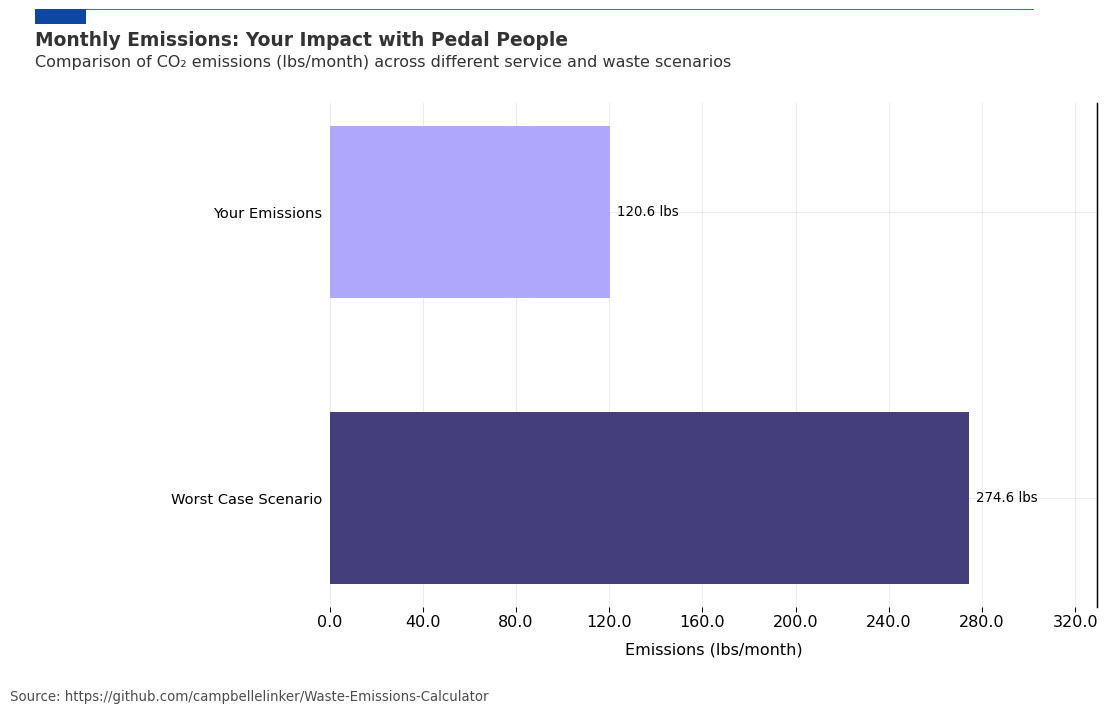

In [ ]:
# https://towardsdatascience.com/5-steps-to-build-beautiful-bar-charts-with-python-3691d434117a/

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

With_PP = float(With_PP) # actual emissions (lbs/month)
Without_PP = float(Without_PP) # emissions if customer used a truck company (lbs/month)
With_PP_trash = float(With_PP_trash) # emissions if customer didn't recycle or compost (lbs/month)
Without_PP_trash = float(Without_PP_trash) # emissions if customer didn't recylce or compost AND didn't use PP (lbs/month)

values = [With_PP, Without_PP_trash]
labels = ['Your Emissions', 'Your Worst Case Scenario']

# Sort by value descending
paired = sorted(zip(values, labels), key=lambda x: x[0], reverse=True)
values, labels = zip(*paired)
values = list(values)
labels = list(labels)

# Create the figure and axes objects, specify the size and the dots per inches 
fig, ax = plt.subplots(figsize=(13.33, 7.5), dpi=96)

# Colours - Choose the extreme colours of the colour map
colours = ["#afa8fa", "#443e7d"]  # light blue → dark blue

# Colormap - Build the colour maps
cmap = mpl.colors.LinearSegmentedColormap.from_list("colour_map", colours, N=256)
norm = mpl.colors.Normalize(min(values), max(values))

# Plot horizontal bars
bar1 = ax.barh(labels, values, color=cmap(norm(values)), height=0.6, zorder=2)

# Create the grid 
ax.grid(which="major", axis='x', color='#DAD8D7', alpha=0.5, zorder=1)
ax.grid(which="major", axis='y', color='#DAD8D7', alpha=0.5, zorder=1)

# Reformat x-axis label and tick labels
ax.set_xlabel('Emissions (lbs/month)', fontsize=12, labelpad=10)
ax.xaxis.set_label_position("bottom")
ax.xaxis.set_major_formatter(lambda s, i: f'{s:,.1f}')
ax.xaxis.set_major_locator(MaxNLocator(integer=False))
ax.xaxis.set_tick_params(pad=2, labelbottom=True, bottom=True, labelsize=12, labelrotation=0)

# Reformat y-axis
ax.set_ylabel('', fontsize=12, labelpad=10)
ax.yaxis.set_label_position("left")
ax.yaxis.set_tick_params(pad=2, labeltop=False, labelbottom=True, bottom=False, labelsize=11)

# Add label on top of each bar
ax.bar_label(bar1, labels=[f'{v:,.1f} lbs' for v in values], padding=5, color='black', fontsize=10)

# Remove the spines
ax.spines[['top','left','bottom']].set_visible(False)

# Make the left spine thicker
ax.spines['right'].set_linewidth(1.1)

# Add in red line and rectangle on top
ax.plot([0.12, .9], [.98, .98], transform=fig.transFigure, clip_on=False, color="#0d47a1", linewidth=.6)
ax.add_patch(plt.Rectangle((0.12,.98), 0.04, -0.02, facecolor="#0d47a1", transform=fig.transFigure, clip_on=False, linewidth = 0))

# Add in title and subtitle
ax.text(x=0.12, y=.93, s="Monthly Emissions: Your Impact with Pedal People", transform=fig.transFigure, ha='left', fontsize=14, weight='bold', alpha=.8)
ax.text(x=0.12, y=.90, s="Comparison of CO₂ emissions (lbs/month) across different service and waste scenarios", transform=fig.transFigure, ha='left', fontsize=12, alpha=.8)

# Set source text
ax.text(x=0.1, y=0.02, s="Source: https://github.com/campbellelinker/Waste-Emissions-Calculator", transform=fig.transFigure, ha='left', fontsize=10, alpha=.7)

# Extend x-axis slightly to make room for bar labels
ax.set_xlim(right=max(values) * 1.2)

# Adjust the margins around the plot area
plt.subplots_adjust(left=0.35, bottom=0.15, right=0.95, top=0.85, wspace=None, hspace=None)

# Set a white background
fig.patch.set_facecolor('white')

plt.show()